In [1]:
const PROJECT_ROOT = joinpath(homedir(), "work", "Deborah.jl")
function localpath(relpath::AbstractString)
    return joinpath(PROJECT_ROOT, relpath)
end
# using Revise
import Deborah.Rebekah; flush(stdout); flush(stderr)
import Deborah.RebekahMiriam;  flush(stdout); flush(stderr)

┌ Info: lib_lightgbm found in system dirs!
└ @ LightGBM /home/benjamin/.julia/packages/LightGBM/qTqmS/src/LightGBM.jl:37


In [2]:
SAVE_DIR="sample"
ns="12"
nt="4"
beta="1.60"
# model="Plaq-Rect-Loop-TrM1_GBM_Plaq-Rect-Loop-TrM2_GBM_Plaq-Rect-Loop-TrM3_GBM_Plaq-Rect-Loop-TrM4_GBM"
model="Plaq-Rect-TrM1_GBM_Plaq-Rect-TrM2_GBM_Plaq-Rect-TrM3_GBM_Plaq-Rect-TrM4_GBM"
# model="TrM1-TrM1_BAS_TrM1-TrM2_GBM_TrM1-TrM3_GBM_TrM1-TrM4_GBM"

"Plaq-Rect-TrM1_GBM_Plaq-Rect-TrM2_GBM_Plaq-Rect-TrM3_GBM_Plaq-Rect-TrM4_GBM"

In [3]:
overall_name="L$(ns)T$(nt)b$(beta)_$(model)"

# --- Load result ---
result = Rebekah.JLD2Loader.load_jld2_Miriam(localpath("$(SAVE_DIR)/results_$(overall_name).jld2"))

rw_data = result.rw_data
new_dict = result.summary
new_dict_trace_meas = result.summary_trace_meas
new_dict_moment_meas = result.summary_moment_meas
new_dict_cumulant_meas = result.summary_cumulant_meas
nlsolve_status = result.nlsolve_status
kappa_list = result.kappa_list
labels = result.labels
trains = result.trains

labels_int = parse.(Int, labels)
trains_int = parse.(Int, trains)   

Rebekah.PyPlotLaTeX.set_pyplot_latex_style()

save_flag=true

true

In [4]:
available = RebekahMiriam.HeatmapsRebekahMiriam.collect_available_solvers(nlsolve_status)

4-element Vector{String}:
 "nlsolve_f_solver_FULL-LBOG-ULML"
 "nlsolve_f_solver_FULL-LBOG-ULOG"
 "nlsolve_f_solver_LABL-TROG-BCML"
 "nlsolve_f_solver_LABL-TROG-BCOG"

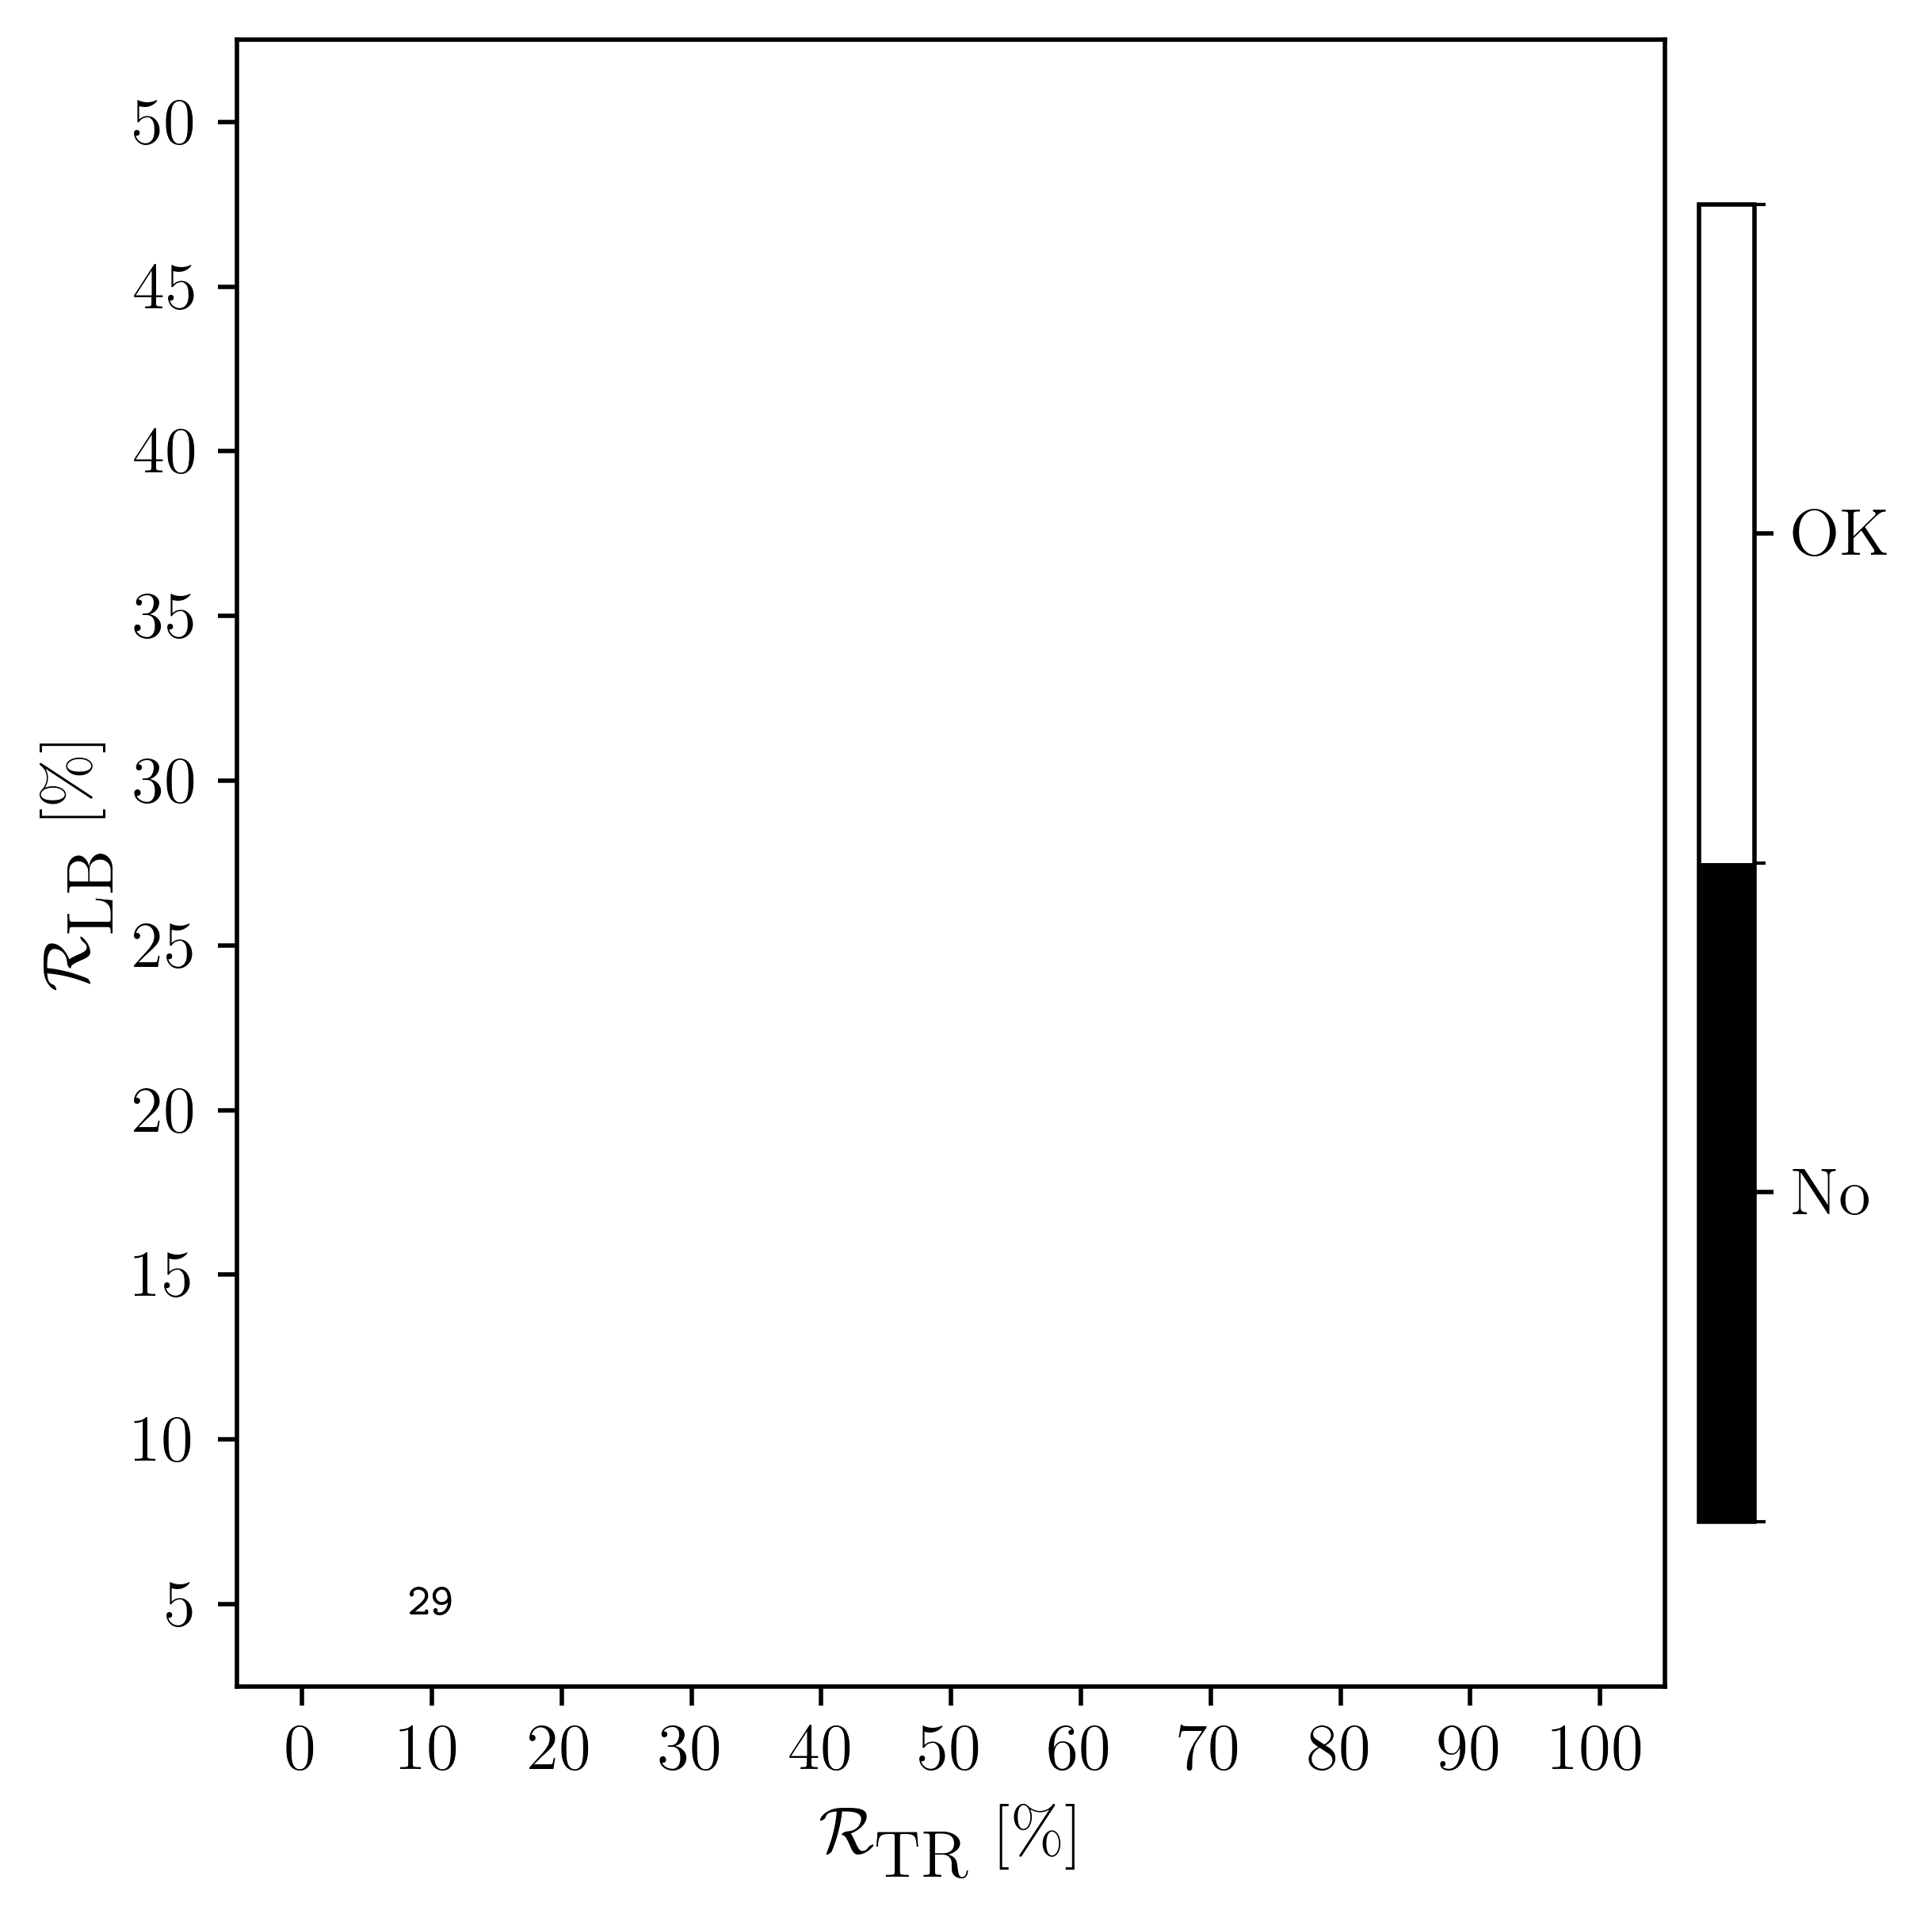

PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `./nlsolve_conv_nlsolve_f_solver_FULL-LBOG-ULML_L12T4b1.60_Plaq-Rect-TrM1_GBM_Plaq-Rect-TrM2_GBM_Plaq-Rect-TrM3_GBM_Plaq-Rect-TrM4_GBM-crop.pdf'.


In [5]:
solver = available[1]
conv_arr, resn_arr, iter_arr = RebekahMiriam.HeatmapsRebekahMiriam.build_nlsolve_grids(nlsolve_status, labels, trains, solver)

RebekahMiriam.HeatmapsRebekahMiriam.render_nlsolve_convergence_heatmap(
    conv_arr, resn_arr, iter_arr, parse.(Int, labels), parse.(Int, trains),
    solver, overall_name, "."; save_file=save_flag
)